In [1]:
import kagglehub
vipoooool_new_plant_diseases_dataset_path = kagglehub.dataset_download('vipoooool/new-plant-diseases-dataset')
print('Data source import complete.')

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Data source import complete.


In [4]:
import numpy as np
import pandas as pd
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
os.makedirs('/content/plant_disease', exist_ok=True)

print("TensorFlow version:", tf.__version__)


ValueError: mount failed

In [ ]:
# Clear session before anything
tf.keras.backend.clear_session()
gc.collect()

# Allow GPU to grow memory gradually instead of grabbing it all
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU ready: {gpus}")
else:
    print("⚠️ No GPU — go to Runtime → Change runtime type → T4 GPU")

# Set mixed precision ONCE here, never again
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision: float16")

In [ ]:
base = '/kaggle/input'
root_path = None

for dirpath, dirnames, filenames in os.walk(base):
    if 'train' in dirnames and 'valid' in dirnames:
        root_path = dirpath
        break

if root_path is None:
    raise FileNotFoundError("❌ Could not find 'train' and 'valid' folders.")

train_path = os.path.join(root_path, 'train')
valid_path = os.path.join(root_path, 'valid')

print(f"✅ Train: {train_path}")
print(f"✅ Valid: {valid_path}")
print(f"📂 Train classes: {len(os.listdir(train_path))}")
print(f"📂 Valid classes: {len(os.listdir(valid_path))}")

In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16        # Keep low — free Colab RAM is tight
AUTOTUNE   = tf.data.AUTOTUNE

# Get class names from the directory structure
class_names = sorted(os.listdir(train_path))
NUM_CLASSES = len(class_names)

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    seed=42
).prefetch(buffer_size=AUTOTUNE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
).prefetch(buffer_size=AUTOTUNE)


print(f"✅ {NUM_CLASSES} classes loaded")

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

print("✅ Augmentation ready.")

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False
print(f"Base model layers: {len(base_model.layers)}")

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = data_augmentation(inputs)
x       = layers.Rescaling(1./127.5, offset=-1)(x)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)  # float32 keeps loss stable

model = tf.keras.Model(inputs, outputs)  # ← THIS LINE WAS MISSING

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
PHASE1_EPOCHS = 15

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/plant_disease/best_phase1.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("🚀 Phase 1: Training top layers (base frozen)...")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks_phase1
)

In [ ]:
base_model.trainable = True
FINE_TUNE_FROM = len(base_model.layers) - 50

for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

trainable_count = sum([1 for l in base_model.layers if l.trainable])
print(f"✅ Fine-tuning top {trainable_count} layers")

PHASE2_EPOCHS = 15

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/plant_disease/best_phase2.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("🔥 Phase 2: Fine-tuning...")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_phase2
)

In [ ]:
def plot_history(h1, h2):
    acc      = h1.history['accuracy']     + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss     = h1.history['loss']         + h2.history['loss']
    val_loss = h1.history['val_loss']     + h2.history['val_loss']
    phase2_start = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    ax1.plot(acc, label='Train Accuracy')
    ax1.plot(val_acc, label='Val Accuracy')
    ax1.axvline(x=phase2_start, color='red', linestyle='--', label='Fine-tuning Start')
    ax1.set_title('Accuracy Over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(loss, label='Train Loss')
    ax2.plot(val_loss, label='Val Loss')
    ax2.axvline(x=phase2_start, color='red', linestyle='--', label='Fine-tuning Start')
    ax2.set_title('Loss Over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history1, history2)

In [ ]:
print("📊 Evaluating...")
loss, acc = model.evaluate(val_ds, verbose=1)
print(f"✅ Accuracy : {acc * 100:.2f}%")
print(f"✅ Loss     : {loss:.4f}")

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
save_path = '/content/drive/MyDrive/plant_disease/plant_disease_model.keras'
model.save(save_path)
print(f"✅ Model saved to {save_path}")

plt.figure(figsize=(16, 8))
for images, labels in val_ds.take(1):
    preds       = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    confidence  = np.max(preds, axis=1)

    n = min(12, len(images))
    for i in range(n):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().clip(0, 255).astype("uint8"))
        true_name = class_names[labels[i]]
        pred_name = class_names[pred_labels[i]]
        color = "green" if true_name == pred_name else "red"
        plt.title(f"P: {pred_name}\nT: {true_name}\n{confidence[i]*100:.1f}%",
                  fontsize=7, color=color)
        plt.axis("off")

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# -*- coding: utf-8 -*-
"""plantDiseaseModel_fixed.ipynb"""

import kagglehub
vipoooool_new_plant_diseases_dataset_path = kagglehub.dataset_download('vipoooool/new-plant-diseases-dataset')
print('Data source import complete.')

import numpy as np
import pandas as pd
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report

# ── No Drive mount ── save locally instead ──────────────────────────────────
os.makedirs('/content/plant_disease', exist_ok=True)

print("TensorFlow version:", tf.__version__)

# Clear session before anything
tf.keras.backend.clear_session()
gc.collect()

# Allow GPU to grow memory gradually instead of grabbing it all
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU ready: {gpus}")
else:
    print("⚠️ No GPU — go to Runtime → Change runtime type → T4 GPU")

# Set mixed precision ONCE here, never again
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision: float16")

# ── Dataset path ─────────────────────────────────────────────────────────────
# kagglehub downloads to ~/.cache/kagglehub/... so search from there
base = vipoooool_new_plant_diseases_dataset_path
root_path = None

for dirpath, dirnames, filenames in os.walk(base):
    if 'train' in dirnames and 'valid' in dirnames:
        root_path = dirpath
        break

if root_path is None:
    raise FileNotFoundError("❌ Could not find 'train' and 'valid' folders.")

train_path = os.path.join(root_path, 'train')
valid_path = os.path.join(root_path, 'valid')

print(f"✅ Train: {train_path}")
print(f"✅ Valid: {valid_path}")
print(f"📂 Train classes: {len(os.listdir(train_path))}")
print(f"📂 Valid classes: {len(os.listdir(valid_path))}")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 16        # Keep low — free Colab RAM is tight
AUTOTUNE   = tf.data.AUTOTUNE

# Get class names from the directory structure
class_names = sorted(os.listdir(train_path))
NUM_CLASSES = len(class_names)

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    seed=42
).prefetch(buffer_size=AUTOTUNE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
).prefetch(buffer_size=AUTOTUNE)

print(f"✅ {NUM_CLASSES} classes loaded")

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

print("✅ Augmentation ready.")

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False
print(f"Base model layers: {len(base_model.layers)}")

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = data_augmentation(inputs)
x       = layers.Rescaling(1./127.5, offset=-1)(x)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)  # float32 keeps loss stable

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── Phase 1: Train top layers (base frozen) ───────────────────────────────────
PHASE1_EPOCHS = 15

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1),
    ModelCheckpoint('/content/plant_disease/best_phase1.keras',          # ← fixed path
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("🚀 Phase 1: Training top layers (base frozen)...")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks_phase1
)

# ── Phase 2: Fine-tuning ──────────────────────────────────────────────────────
base_model.trainable = True
FINE_TUNE_FROM = len(base_model.layers) - 50

for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

trainable_count = sum([1 for l in base_model.layers if l.trainable])
print(f"✅ Fine-tuning top {trainable_count} layers")

PHASE2_EPOCHS = 15

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1),
    ModelCheckpoint('/content/plant_disease/best_phase2.keras',          # ← fixed path
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("🔥 Phase 2: Fine-tuning...")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_phase2
)

# ── Plot training history ─────────────────────────────────────────────────────
def plot_history(h1, h2):
    acc      = h1.history['accuracy']     + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss     = h1.history['loss']         + h2.history['loss']
    val_loss = h1.history['val_loss']     + h2.history['val_loss']
    phase2_start = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    ax1.plot(acc, label='Train Accuracy')
    ax1.plot(val_acc, label='Val Accuracy')
    ax1.axvline(x=phase2_start, color='red', linestyle='--', label='Fine-tuning Start')
    ax1.set_title('Accuracy Over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(loss, label='Train Loss')
    ax2.plot(val_loss, label='Val Loss')
    ax2.axvline(x=phase2_start, color='red', linestyle='--', label='Fine-tuning Start')
    ax2.set_title('Loss Over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history1, history2)

# ── Evaluation ────────────────────────────────────────────────────────────────
print("📊 Evaluating...")
loss, acc = model.evaluate(val_ds, verbose=1)
print(f"✅ Accuracy : {acc * 100:.2f}%")
print(f"✅ Loss     : {loss:.4f}")

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

# ── Save model ────────────────────────────────────────────────────────────────
save_path = '/content/plant_disease/plant_disease_model.keras'           # ← fixed path + .keras extension
model.save(save_path)
print(f"✅ Model saved to {save_path}")

# ── Sample predictions ────────────────────────────────────────────────────────
plt.figure(figsize=(16, 8))
for images, labels in val_ds.take(1):
    preds       = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    confidence  = np.max(preds, axis=1)

    n = min(12, len(images))                                             # ← guard against small batches
    for i in range(n):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().clip(0, 255).astype("uint8"))      # ← clip before cast
        true_name = class_names[labels[i]]
        pred_name = class_names[pred_labels[i]]
        color = "green" if true_name == pred_name else "red"
        plt.title(f"P: {pred_name}\nT: {true_name}\n{confidence[i]*100:.1f}%",
                  fontsize=7, color=color)
        plt.axis("off")

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.show()

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Data source import complete.
TensorFlow version: 2.20.0
✅ GPU ready: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Mixed precision: float16
✅ Train: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
✅ Valid: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
📂 Train classes: 38
📂 Valid classes: 38
Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
✅ 38 classes loaded
✅ Augmentation ready.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model layers: 154


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

🚀 Phase 1: Training top layers (base frozen)...
Epoch 1/15
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7691 - loss: 0.8331
Epoch 1: val_accuracy improved from None to 0.91486, saving model to /content/plant_disease/best_phase1.keras

Epoch 1: finished saving model to /content/plant_disease/best_phase1.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 411s 88ms/step - accuracy: 0.8551 - loss: 0.4867 - val_accuracy: 0.9149 - val_loss: 0.2647 - learning_rate: 0.0010
Epoch 2/15
4392/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9041 - loss: 0.3018
Epoch 2: val_accuracy improved from 0.91486 to 0.92733, saving model to /content/plant_disease/best_phase1.keras

Epoch 2: finished saving model to /content/plant_disease/best_phase1.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 185s 42ms/step - accuracy: 0.9062 - loss: 0.2953 - val_accuracy: 0.9273 - val_loss: 0.2232 - learning_rate: 0.0010
Epoch 3/15
4392/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9107 - loss: 0.2778
Epoch 3: val_accur

KeyboardInterrupt: 

📥 Downloading dataset...
Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
✅ Dataset downloaded to: /kaggle/input/new-plant-diseases-dataset
✅ All imports successful
TensorFlow version: 2.20.0
✅ Save directory ready: /content/plant_disease
✅ GPU ready: ['/physical_device:GPU:0']
✅ Mixed precision policy: float16
✅ Train path : /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
✅ Valid path : /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
📂 Train classes: 38
📂 Valid classes: 38
✅ 38 classes found
✅ LabelEncoder saved to /content/plant_disease/label_encoder.pkl
✅ Class names saved to /content/plant_disease/class_names.json
Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
✅ Datasets loaded and prefetched
✅ Augmentation pipeline ready
✅ MobileNetV2 loaded — 154 layers (frozen)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


🚀 Phase 1: Training top layers (base frozen)...
Epoch 1/15
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7696 - loss: 0.8235
Epoch 1: val_accuracy improved from None to 0.91964, saving model to /content/plant_disease/best_phase1.keras

Epoch 1: finished saving model to /content/plant_disease/best_phase1.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 223s 46ms/step - accuracy: 0.8550 - loss: 0.4821 - val_accuracy: 0.9196 - val_loss: 0.2558 - learning_rate: 0.0010
Epoch 2/15
4393/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9028 - loss: 0.2997
Epoch 2: val_accuracy improved from 0.91964 to 0.92761, saving model to /content/plant_disease/best_phase1.keras

Epoch 2: finished saving model to /content/plant_disease/best_phase1.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 184s 42ms/step - accuracy: 0.9065 - loss: 0.2918 - val_accuracy: 0.9276 - val_loss: 0.2219 - learning_rate: 0.0010
Epoch 3/15
4392/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9115 - loss: 0.2752
Epoch 3: val_accu

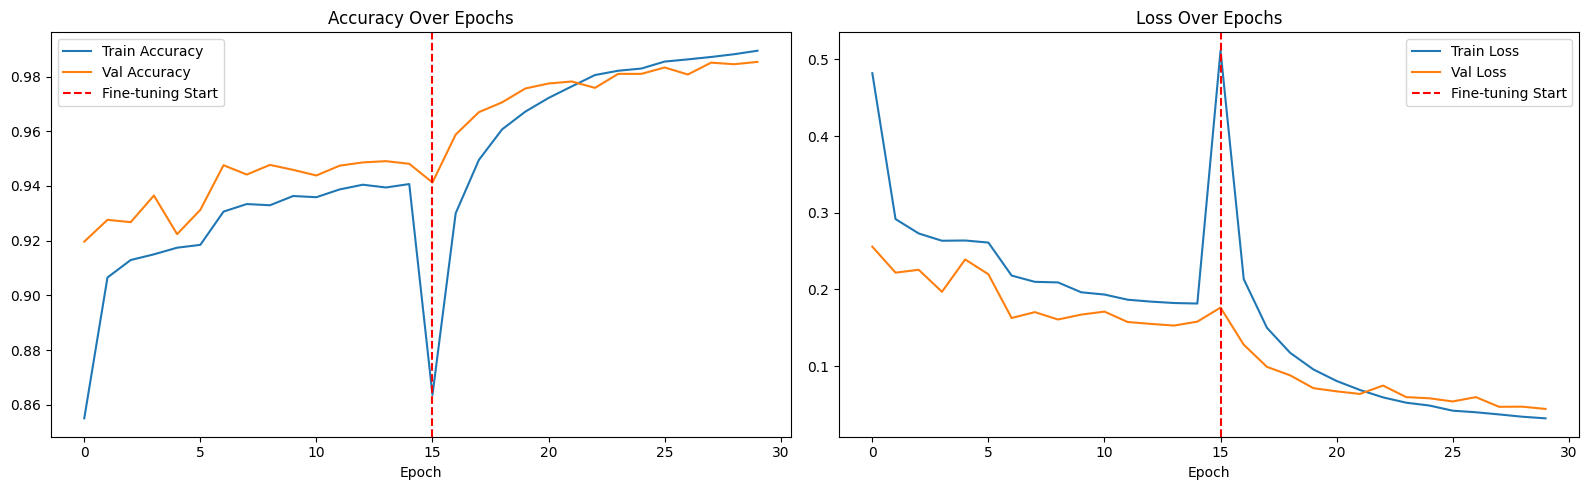

✅ Training history plot saved

📊 Evaluating on validation set...
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - accuracy: 0.9854 - loss: 0.0441
✅ Accuracy : 98.54%
✅ Loss     : 0.0441

📋 Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00       504
                                 Apple___Black_rot       0.99      1.00      1.00       497
                          Apple___Cedar_apple_rust       1.00      0.99      1.00       440
                                   Apple___healthy       1.00      0.98      0.99       502
                               Blueberry___healthy       1.00      1.00      1.00       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       421
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   

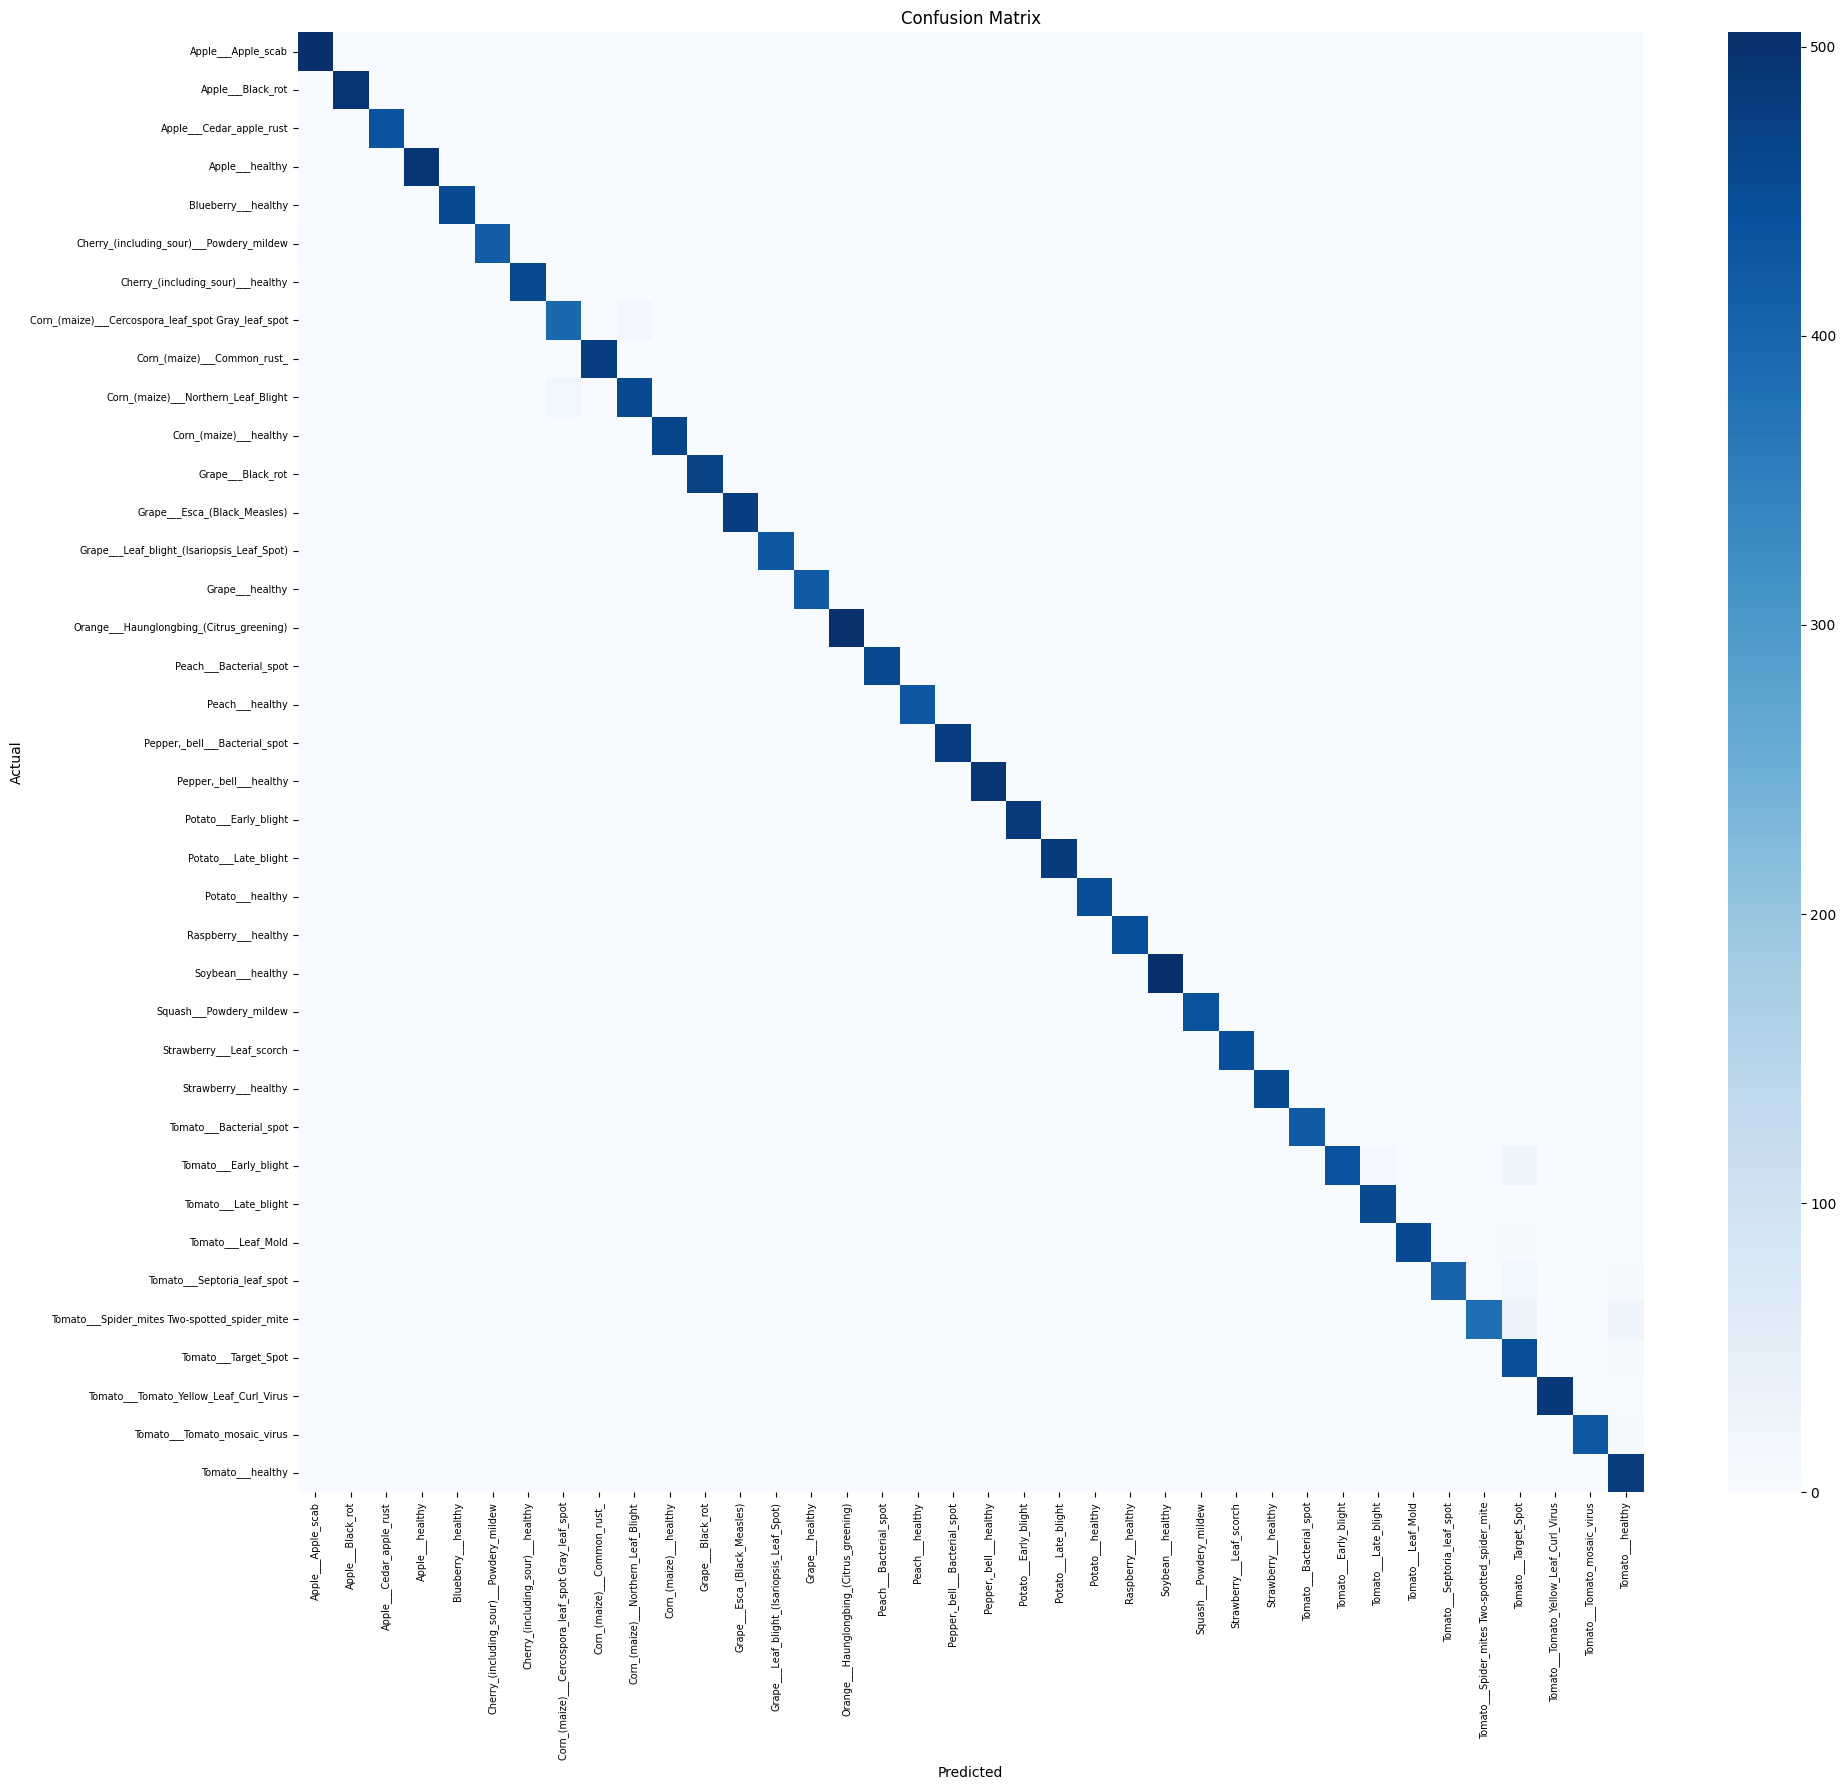

✅ Confusion matrix saved
✅ Final model saved to /content/plant_disease/plant_disease_model.keras
✅ Model reload verification passed

🖼️ Generating sample predictions...


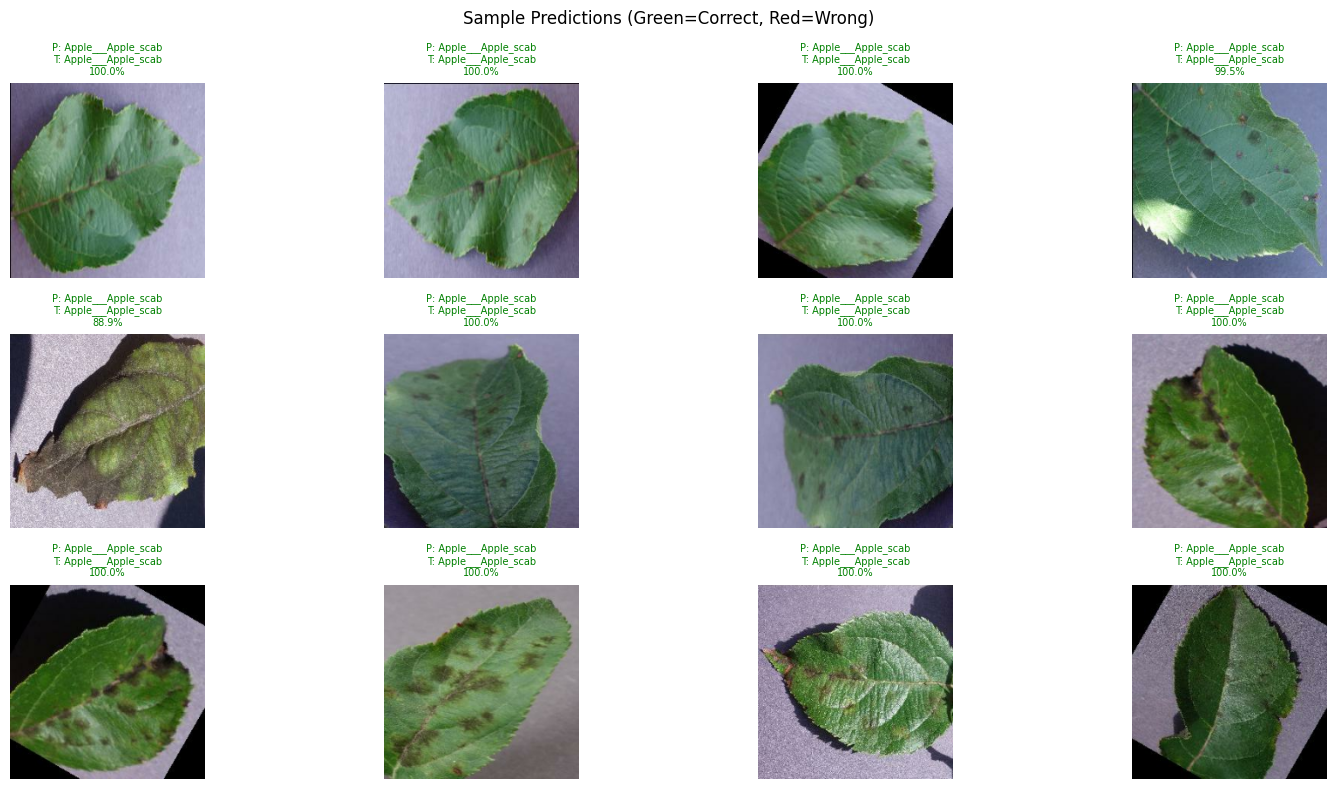

✅ Sample predictions saved

🎉 TRAINING COMPLETE — files saved to: /content/plant_disease
  📄 best_phase1.keras                             10.13 MB
  📄 best_phase2.keras                             38.50 MB
  📄 class_names.json                              0.00 MB
  📄 classification_report.txt                     0.00 MB
  📄 confusion_matrix.png                          0.32 MB
  📄 label_encoder.pkl                             0.01 MB
  📄 plant_disease_model.keras                     38.50 MB
  📄 sample_predictions.png                        1.53 MB
  📄 training_history.png                          0.12 MB


In [3]:
# -*- coding: utf-8 -*-
"""plantDiseaseModel_final.ipynb"""

# ── Step 0: Install / import kagglehub ───────────────────────────────────────
try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "kagglehub", "-q"], check=True)
    import kagglehub

# ── Step 1: Download dataset ──────────────────────────────────────────────────
print("📥 Downloading dataset...")
try:
    dataset_path = kagglehub.dataset_download('vipoooool/new-plant-diseases-dataset')
    print(f"✅ Dataset downloaded to: {dataset_path}")
except Exception as e:
    raise RuntimeError(f"❌ Dataset download failed: {e}")

# ── Step 2: Core imports ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import os
import gc
import json
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

print("✅ All imports successful")
print(f"TensorFlow version: {tf.__version__}")

# ── Step 3: Output directory ──────────────────────────────────────────────────
SAVE_DIR = '/content/plant_disease'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Save directory ready: {SAVE_DIR}")

# ── Step 4: GPU setup ─────────────────────────────────────────────────────────
tf.keras.backend.clear_session()
gc.collect()

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU ready: {[g.name for g in gpus]}")
    except RuntimeError as e:
        print(f"⚠️ GPU config error (may already be initialized): {e}")
else:
    print("⚠️ No GPU detected.")
    print("   → Go to Runtime → Change runtime type → T4 GPU and restart.")

# Mixed precision — speeds up training on GPU significantly
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision policy: float16")

# ── Step 5: Find train/valid folders ─────────────────────────────────────────
root_path = None
for dirpath, dirnames, _ in os.walk(dataset_path):
    if 'train' in dirnames and 'valid' in dirnames:
        root_path = dirpath
        break

if root_path is None:
    raise FileNotFoundError(
        "❌ Could not find 'train' and 'valid' folders inside the downloaded dataset. "
        f"Check what's inside: {dataset_path}"
    )

train_path = os.path.join(root_path, 'train')
valid_path = os.path.join(root_path, 'valid')

print(f"✅ Train path : {train_path}")
print(f"✅ Valid path : {valid_path}")
print(f"📂 Train classes: {len(os.listdir(train_path))}")
print(f"📂 Valid classes: {len(os.listdir(valid_path))}")

# ── Step 6: Class names + LabelEncoder ───────────────────────────────────────
class_names = sorted(os.listdir(train_path))
NUM_CLASSES = len(class_names)
print(f"✅ {NUM_CLASSES} classes found")

# Fit a LabelEncoder so index ↔ class name is always consistent
le = LabelEncoder()
le.fit(class_names)

# Save encoder so inference scripts can reload it without re-deriving
encoder_path = os.path.join(SAVE_DIR, 'label_encoder.pkl')
with open(encoder_path, 'wb') as f:
    pickle.dump(le, f)
print(f"✅ LabelEncoder saved to {encoder_path}")

# Save class names as JSON for easy inspection / frontend use
class_names_path = os.path.join(SAVE_DIR, 'class_names.json')
with open(class_names_path, 'w') as f:
    json.dump(class_names, f, indent=2)
print(f"✅ Class names saved to {class_names_path}")

# ── Step 7: Dataset pipeline ──────────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    seed=42
).prefetch(buffer_size=AUTOTUNE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
).prefetch(buffer_size=AUTOTUNE)

print("✅ Datasets loaded and prefetched")

# ── Step 8: Data augmentation ─────────────────────────────────────────────────
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

print("✅ Augmentation pipeline ready")

# ── Step 9: Build model ───────────────────────────────────────────────────────
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False
print(f"✅ MobileNetV2 loaded — {len(base_model.layers)} layers (frozen)")

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = data_augmentation(inputs)
x       = layers.Rescaling(1./127.5, offset=-1)(x)          # normalize to [-1, 1]
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)  # float32 for stable loss

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── Step 10: Phase 1 — train top layers (base frozen) ────────────────────────
PHASE1_EPOCHS = 15
PHASE1_CKPT   = os.path.join(SAVE_DIR, 'best_phase1.keras')

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(PHASE1_CKPT, monitor='val_accuracy', save_best_only=True, verbose=1),
]

print("\n🚀 Phase 1: Training top layers (base frozen)...")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks_phase1
)

# Load best phase 1 checkpoint before fine-tuning
if os.path.exists(PHASE1_CKPT):
    model = tf.keras.models.load_model(PHASE1_CKPT)
    print(f"✅ Best Phase 1 weights loaded from {PHASE1_CKPT}")
else:
    print("⚠️ Phase 1 checkpoint not found — continuing with current weights")

# ── Step 11: Phase 2 — fine-tune top layers of base model ────────────────────
# Safely grab the base model layer by name after reload
try:
    base_model = model.get_layer('mobilenetv2_1.00_224')
except ValueError:
    # fallback: find the MobileNetV2 layer dynamically
    base_model = next(l for l in model.layers if 'mobilenet' in l.name.lower())

base_model.trainable = True
FINE_TUNE_FROM = len(base_model.layers) - 50
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"✅ Fine-tuning top {trainable_count} layers of MobileNetV2")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

PHASE2_EPOCHS = 15
PHASE2_CKPT   = os.path.join(SAVE_DIR, 'best_phase2.keras')

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-8, verbose=1),
    ModelCheckpoint(PHASE2_CKPT, monitor='val_accuracy', save_best_only=True, verbose=1),
]

print("\n🔥 Phase 2: Fine-tuning...")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_phase2
)

# ── Step 12: Load best phase 2 checkpoint ────────────────────────────────────
if os.path.exists(PHASE2_CKPT):
    model = tf.keras.models.load_model(PHASE2_CKPT)
    print(f"✅ Best Phase 2 weights loaded from {PHASE2_CKPT}")
else:
    print("⚠️ Phase 2 checkpoint not found — continuing with current weights")

# ── Step 13: Plot training history ───────────────────────────────────────────
def plot_history(h1, h2):
    acc      = h1.history['accuracy']     + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss     = h1.history['loss']         + h2.history['loss']
    val_loss = h1.history['val_loss']     + h2.history['val_loss']
    phase2_start = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ax1.plot(acc, label='Train Accuracy')
    ax1.plot(val_acc, label='Val Accuracy')
    ax1.axvline(x=phase2_start, color='red', linestyle='--', label='Fine-tuning Start')
    ax1.set_title('Accuracy Over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(loss, label='Train Loss')
    ax2.plot(val_loss, label='Val Loss')
    ax2.axvline(x=phase2_start, color='red', linestyle='--', label='Fine-tuning Start')
    ax2.set_title('Loss Over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=150)
    plt.show()
    print("✅ Training history plot saved")

plot_history(history1, history2)

# ── Step 14: Evaluation ───────────────────────────────────────────────────────
print("\n📊 Evaluating on validation set...")
loss, acc = model.evaluate(val_ds, verbose=1)
print(f"✅ Accuracy : {acc * 100:.2f}%")
print(f"✅ Loss     : {loss:.4f}")

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n📋 Classification Report:")
report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
print(report)

# Save classification report to file
report_path = os.path.join(SAVE_DIR, 'classification_report.txt')
with open(report_path, 'w') as f:
    f.write(report)
print(f"✅ Classification report saved to {report_path}")

# ── Step 15: Confusion matrix ─────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print("✅ Confusion matrix saved")

# ── Step 16: Save final model ─────────────────────────────────────────────────
final_model_path = os.path.join(SAVE_DIR, 'plant_disease_model.keras')
model.save(final_model_path)
print(f"✅ Final model saved to {final_model_path}")

# Verify it reloads cleanly
try:
    test_load = tf.keras.models.load_model(final_model_path)
    print("✅ Model reload verification passed")
    del test_load
    gc.collect()
except Exception as e:
    print(f"⚠️ Model reload verification failed: {e}")

# ── Step 17: Sample predictions visualization ─────────────────────────────────
print("\n🖼️ Generating sample predictions...")
plt.figure(figsize=(16, 8))

for images, labels in val_ds.take(1):
    preds       = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    confidence  = np.max(preds, axis=1)

    n = min(12, len(images))
    for i in range(n):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().clip(0, 255).astype("uint8"))
        true_name = class_names[labels[i]]
        pred_name = class_names[pred_labels[i]]
        color = "green" if true_name == pred_name else "red"
        plt.title(f"P: {pred_name}\nT: {true_name}\n{confidence[i]*100:.1f}%",
                  fontsize=7, color=color)
        plt.axis("off")

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sample_predictions.png'), dpi=150)
plt.show()
print("✅ Sample predictions saved")

# ── Step 18: Final summary ────────────────────────────────────────────────────
print("\n" + "="*55)
print("🎉 TRAINING COMPLETE — files saved to:", SAVE_DIR)
print("="*55)
for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    size  = os.path.getsize(fpath) / (1024 * 1024)
    print(f"  📄 {fname:45s} {size:.2f} MB")

In [4]:
from google.colab import files
import zipfile

# Zip everything up
zip_path = '/content/plant_disease_output.zip'
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for fname in os.listdir(SAVE_DIR):
        zipf.write(os.path.join(SAVE_DIR, fname), fname)

# Download the zip
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>